# TP2 -- Clasificacion Supervisada: EDA y Limpieza

**Materia:** 72.75 Aprendizaje Automatico (Machine Learning) -- ITBA

## 1. Alcance

El objetivo de este notebook es realizar la exploracion, limpieza y preparacion del dataset
**Breast Cancer Wisconsin (Diagnostic)** (WDBC), que contiene 30 features numericos extraidos
de imagenes de aspiraciones con aguja fina (FNA) de masas mamarias.

El trabajo abarca:

1. **Carga y vision general:** importar el dataset, verificar tipos y valores faltantes.
2. **EDA visual:** histogramas, boxplots y distribucion por clase (B/M).
3. **Analisis de correlacion:** identificar features redundantes por multicolinealidad.
4. **Feature selection:** eliminar features con alta correlacion entre si (|r| > 0.80),
   analizando caso por caso para conservar la mas informativa.
5. **Outlier check:** identificar outliers estadisticos sin eliminarlos (datos medicos reales).
6. **Comparacion antes/despues:** visualizar el efecto de la limpieza.
7. **Split y export:** separar train/test estratificado y exportar CSVs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 2. Carga del dataset

El archivo `wdbc.data` no tiene header. Las columnas se asignan segun `wdbc.names`:
- Columna 1: ID
- Columna 2: Diagnosis (B = benigno, M = maligno)
- Columnas 3-12: 10 features (mean)
- Columnas 13-22: 10 features (standard error)
- Columnas 23-32: 10 features (worst = media de los 3 valores mas grandes)

Las 10 features base son: radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension.

In [2]:
FEATURE_NAMES = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension"
]

col_names = ["id", "diagnosis"]
for suffix in ["mean", "se", "worst"]:
    for feat in FEATURE_NAMES:
        col_names.append(f"{feat}_{suffix}")

df = pd.read_csv("wdbc.data", header=None, names=col_names)

print(f"Shape: {df.shape}")
df.head(10)

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [3]:
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
print(f"Columnas restantes: {len(df.columns)} (30 features + 1 target)")
print(f"\ndtypes:\n{df.dtypes.value_counts()}")

Columnas restantes: 31 (30 features + 1 target)

dtypes:
float64    30
int64       1
Name: count, dtype: int64


## 3. Vision general del dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [5]:
df.describe().round(4)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,569.0000,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,0.3726,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,...,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,0.4839,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,...,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,0.0000,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,...,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,0.0000,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,...,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,0.0000,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,...,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,1.0000,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,...,18.7900,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,1.0000,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,...,36.0400,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


In [6]:
print("Valores faltantes por columna:")
print(df.isnull().sum())
print(f"\nTotal: {df.isnull().sum().sum()}")

Valores faltantes por columna:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total: 0


### Distribucion de clases

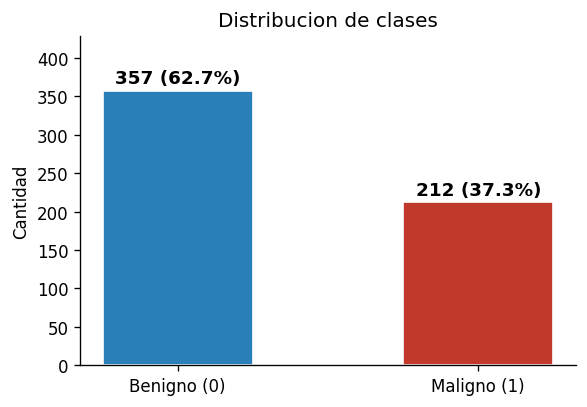


Desbalance: 1.68:1 (B/M)


In [7]:
counts = df["diagnosis"].value_counts().sort_index()
labels = ["Benigno (0)", "Maligno (1)"]
colors = ["#2980B9", "#C0392B"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val} ({100*val/len(df):.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_title("Distribucion de clases")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

print(f"\nDesbalance: {counts[0]/counts[1]:.2f}:1 (B/M)")

## 4. Distribucion de las variables

### Histogramas con curva de Gauss ajustada

Para cada feature se grafica el histograma normalizado junto con la curva de distribucion
normal ajustada. Esto permite visualizar que tan cerca esta cada variable de una normal.

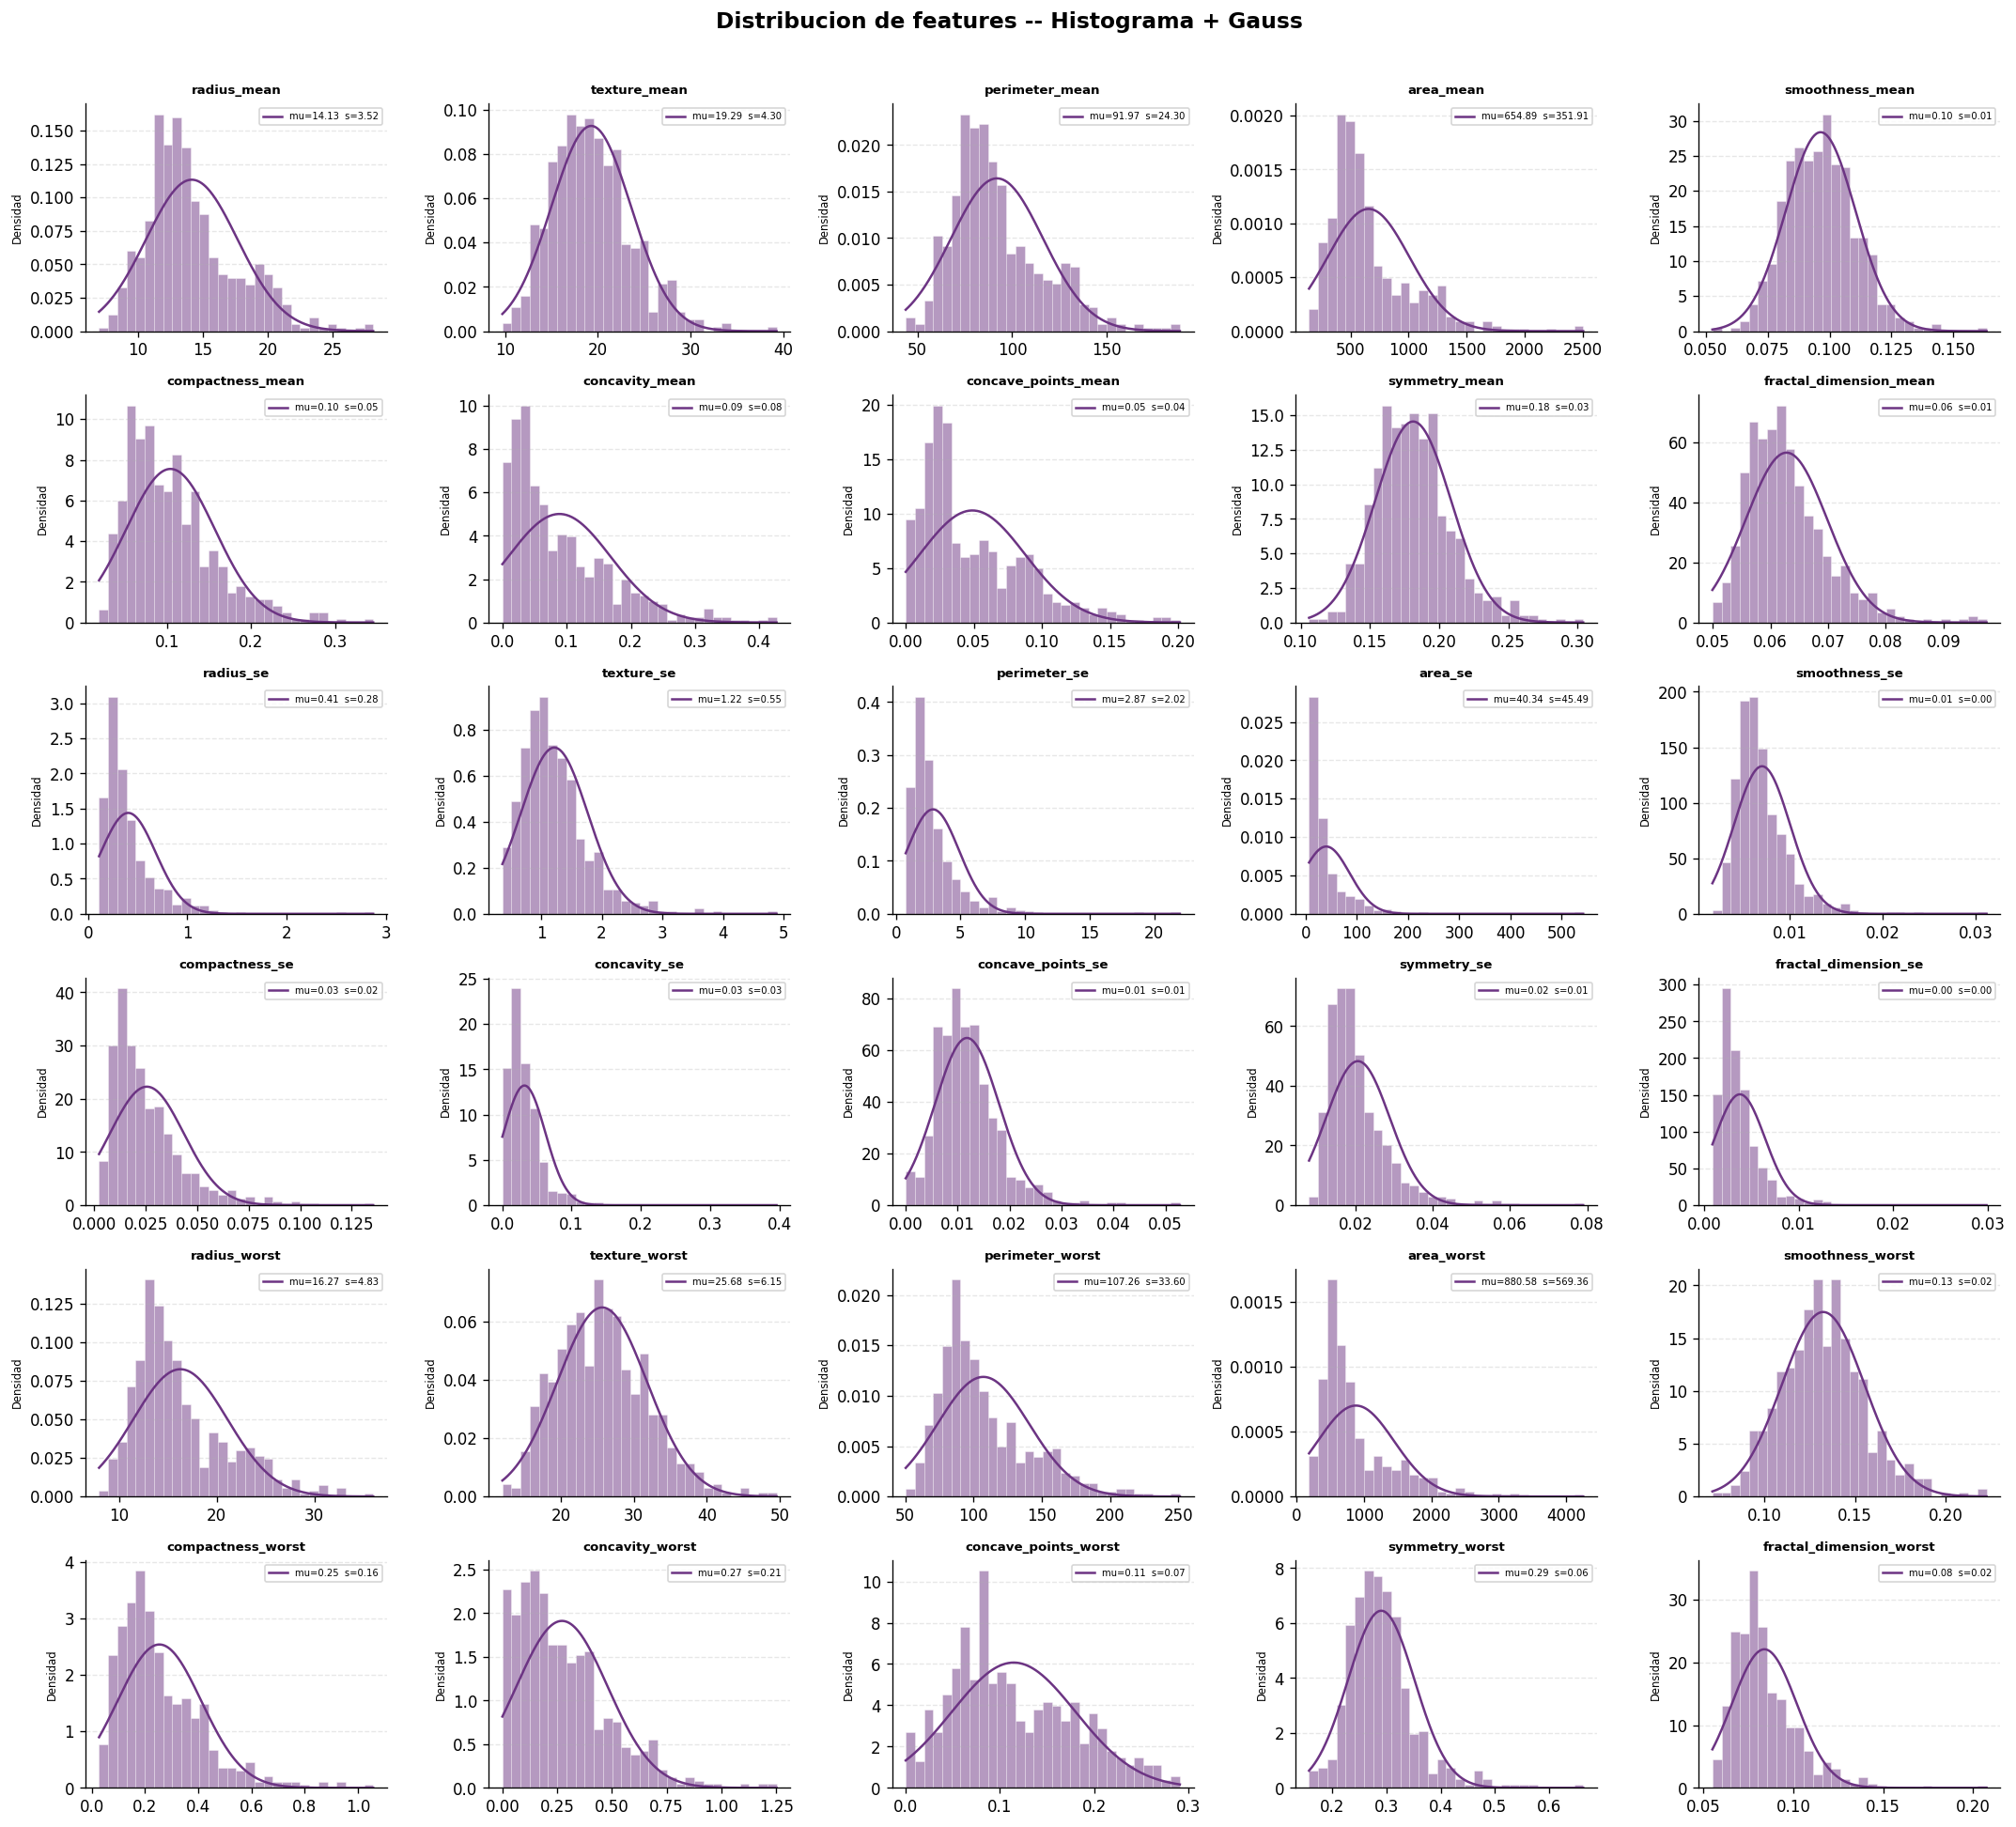

In [8]:
features = [c for c in df.columns if c != "diagnosis"]

fig, axes = plt.subplots(6, 5, figsize=(18, 16))
fig.suptitle("Distribucion de features -- Histograma + Gauss", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    vals = df[feat].dropna()
    ax.hist(vals, bins=30, density=True, color="#6C3483", alpha=0.5, edgecolor="white", linewidth=0.4)
    mu, sigma = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="#6C3483", linewidth=1.5,
            label=f"mu={mu:.2f}  s={sigma:.2f}")
    ax.set_title(feat, fontsize=8, fontweight="bold")
    ax.set_ylabel("Densidad", fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for idx in range(len(features), 30):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Boxplots globales (identificacion de outliers)

Los boxplots muestran la mediana, el rango intercuartilico (IQR) y los valores atipicos
(puntos fuera de los bigotes, calculados como 1.5 * IQR).

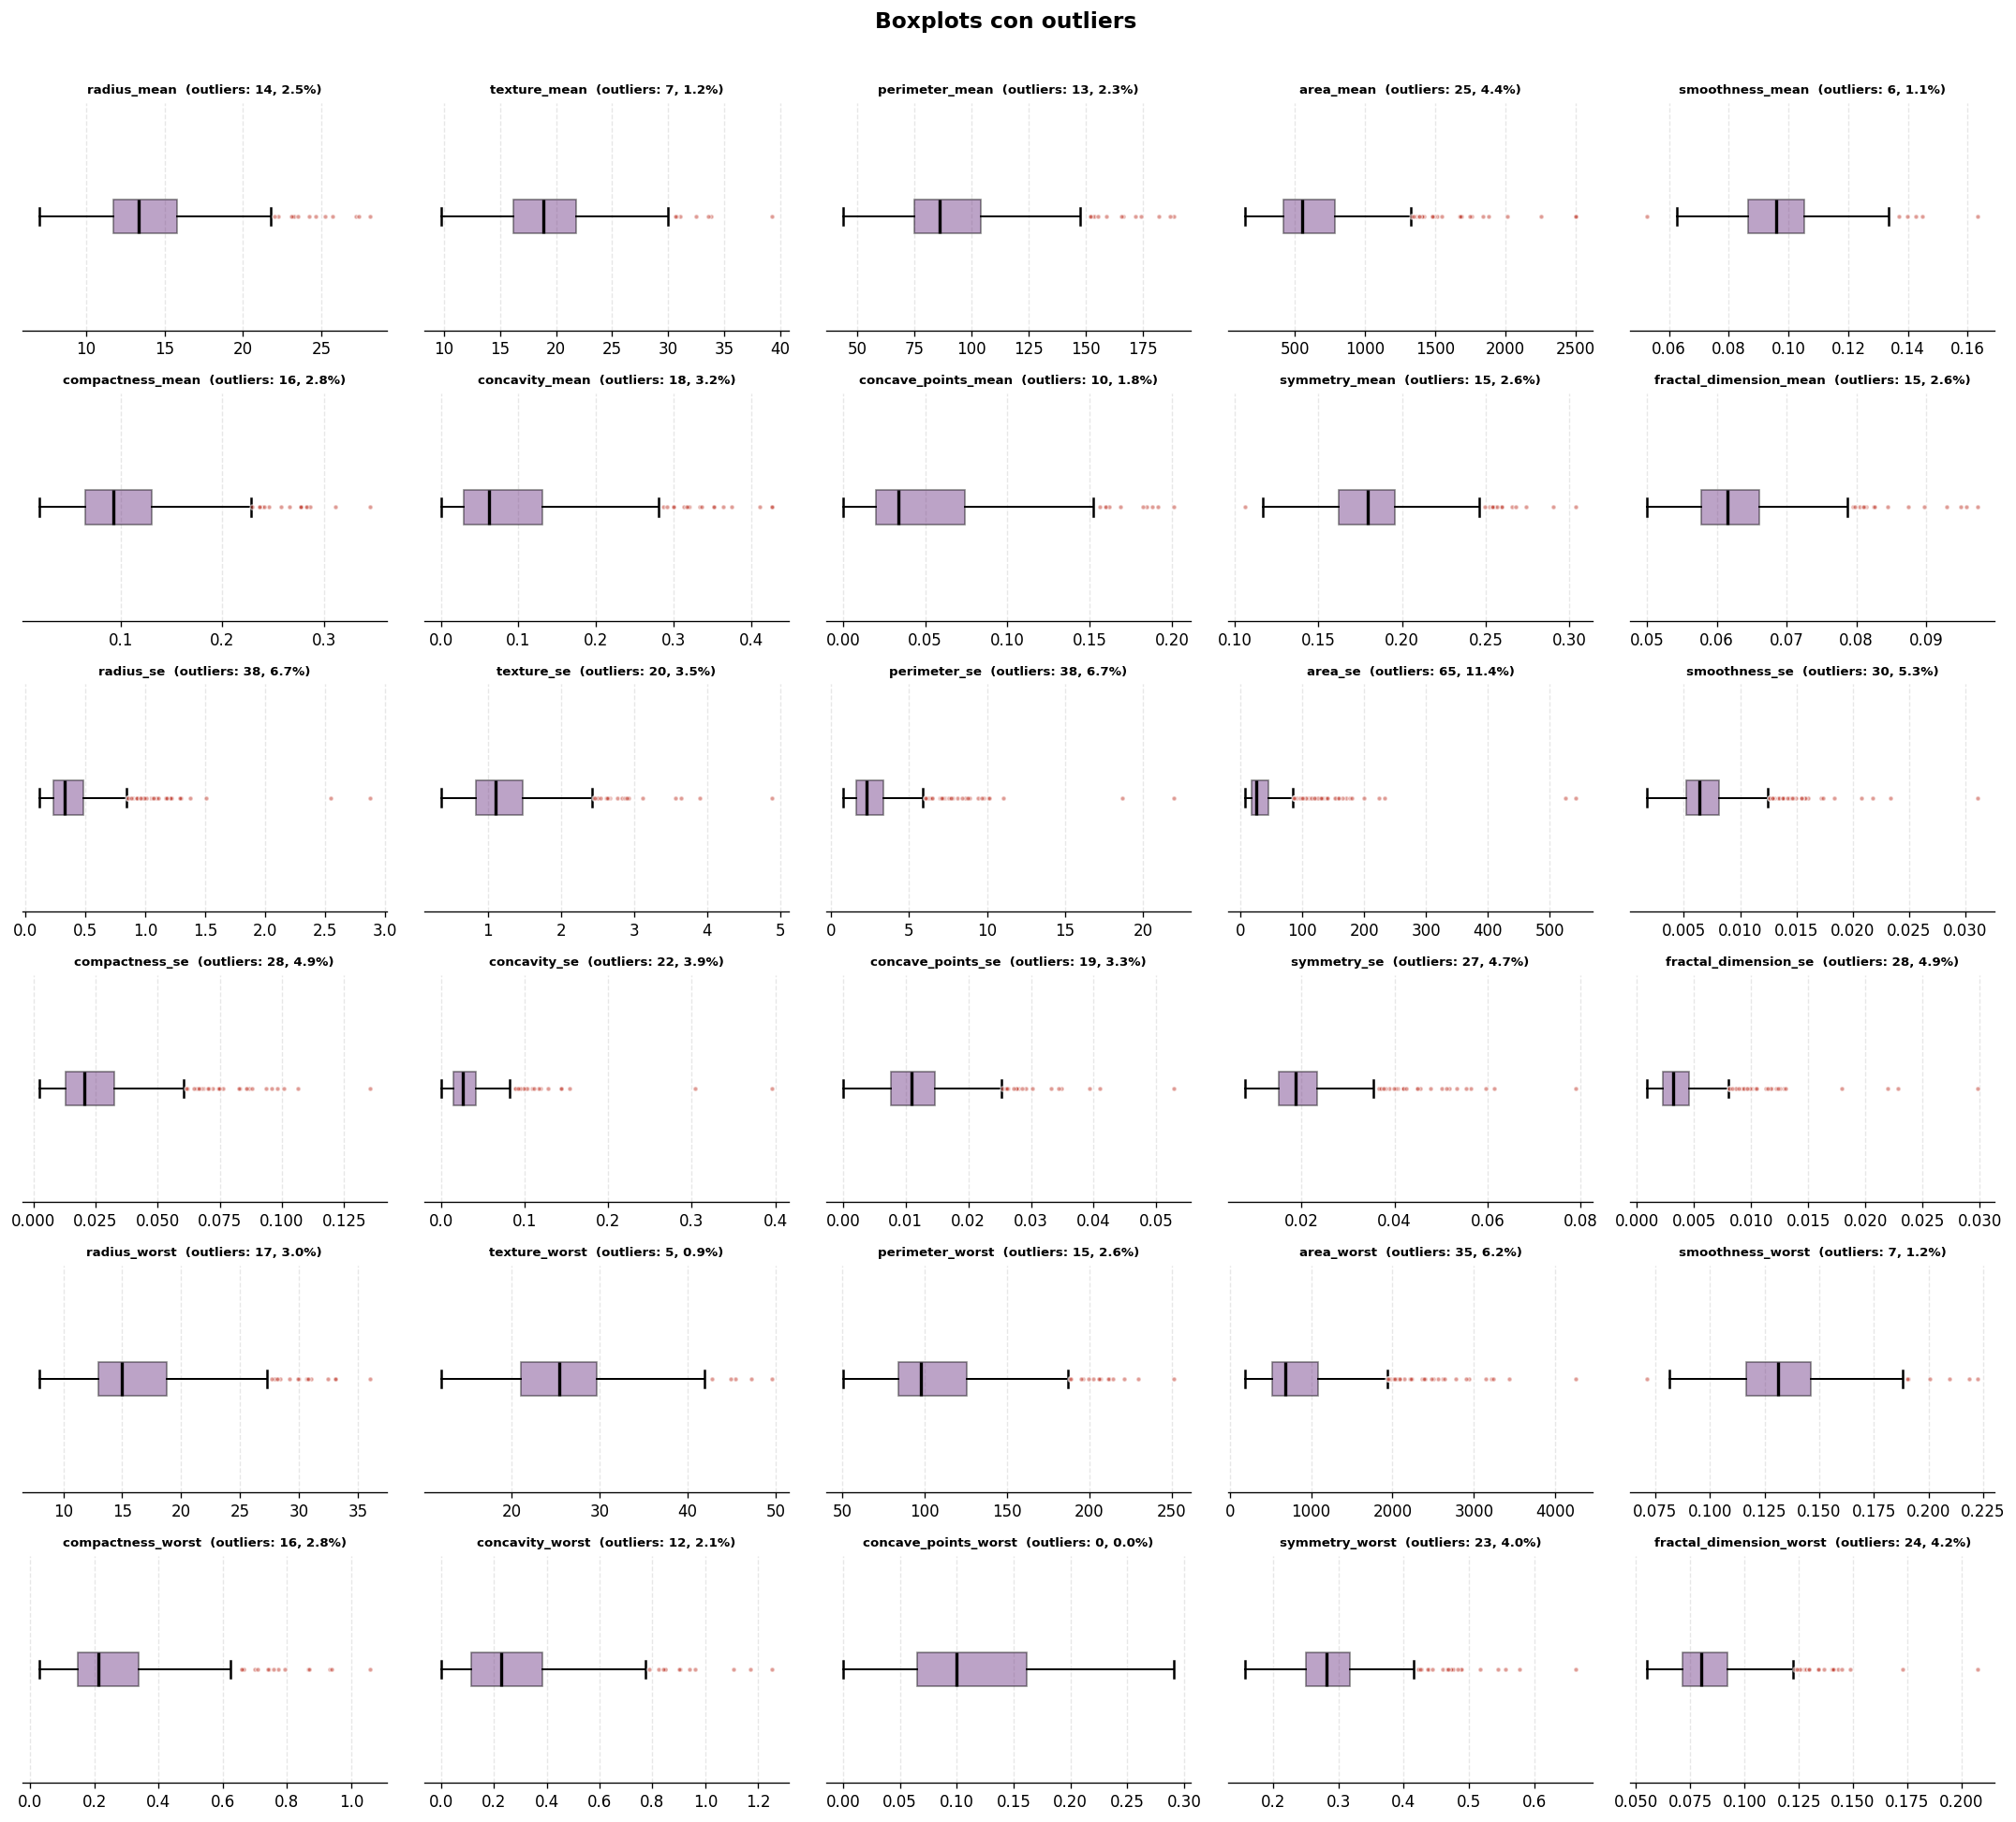

In [9]:
fig, axes = plt.subplots(6, 5, figsize=(18, 16))
fig.suptitle("Boxplots con outliers", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    vals = df[feat].dropna()
    bp = ax.boxplot(vals, vert=False, patch_artist=True,
                    flierprops=dict(marker="o", markerfacecolor="#C0392B",
                                   markeredgecolor="white", markersize=3, alpha=0.5),
                    medianprops=dict(color="black", linewidth=2),
                    boxprops=dict(facecolor="#6C3483", alpha=0.45),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.5))
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    outliers = vals[(vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)]
    pct = 100 * len(outliers) / len(vals)
    ax.set_title(f"{feat}  (outliers: {len(outliers)}, {pct:.1f}%)", fontsize=8, fontweight="bold")
    ax.set_yticks([])
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.spines["left"].set_visible(False)

for idx in range(len(features), 30):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Boxplots por clase (B vs M)

Esta visualizacion es clave para la clasificacion: las features donde las distribuciones
de B y M estan claramente separadas seran las mas discriminativas.

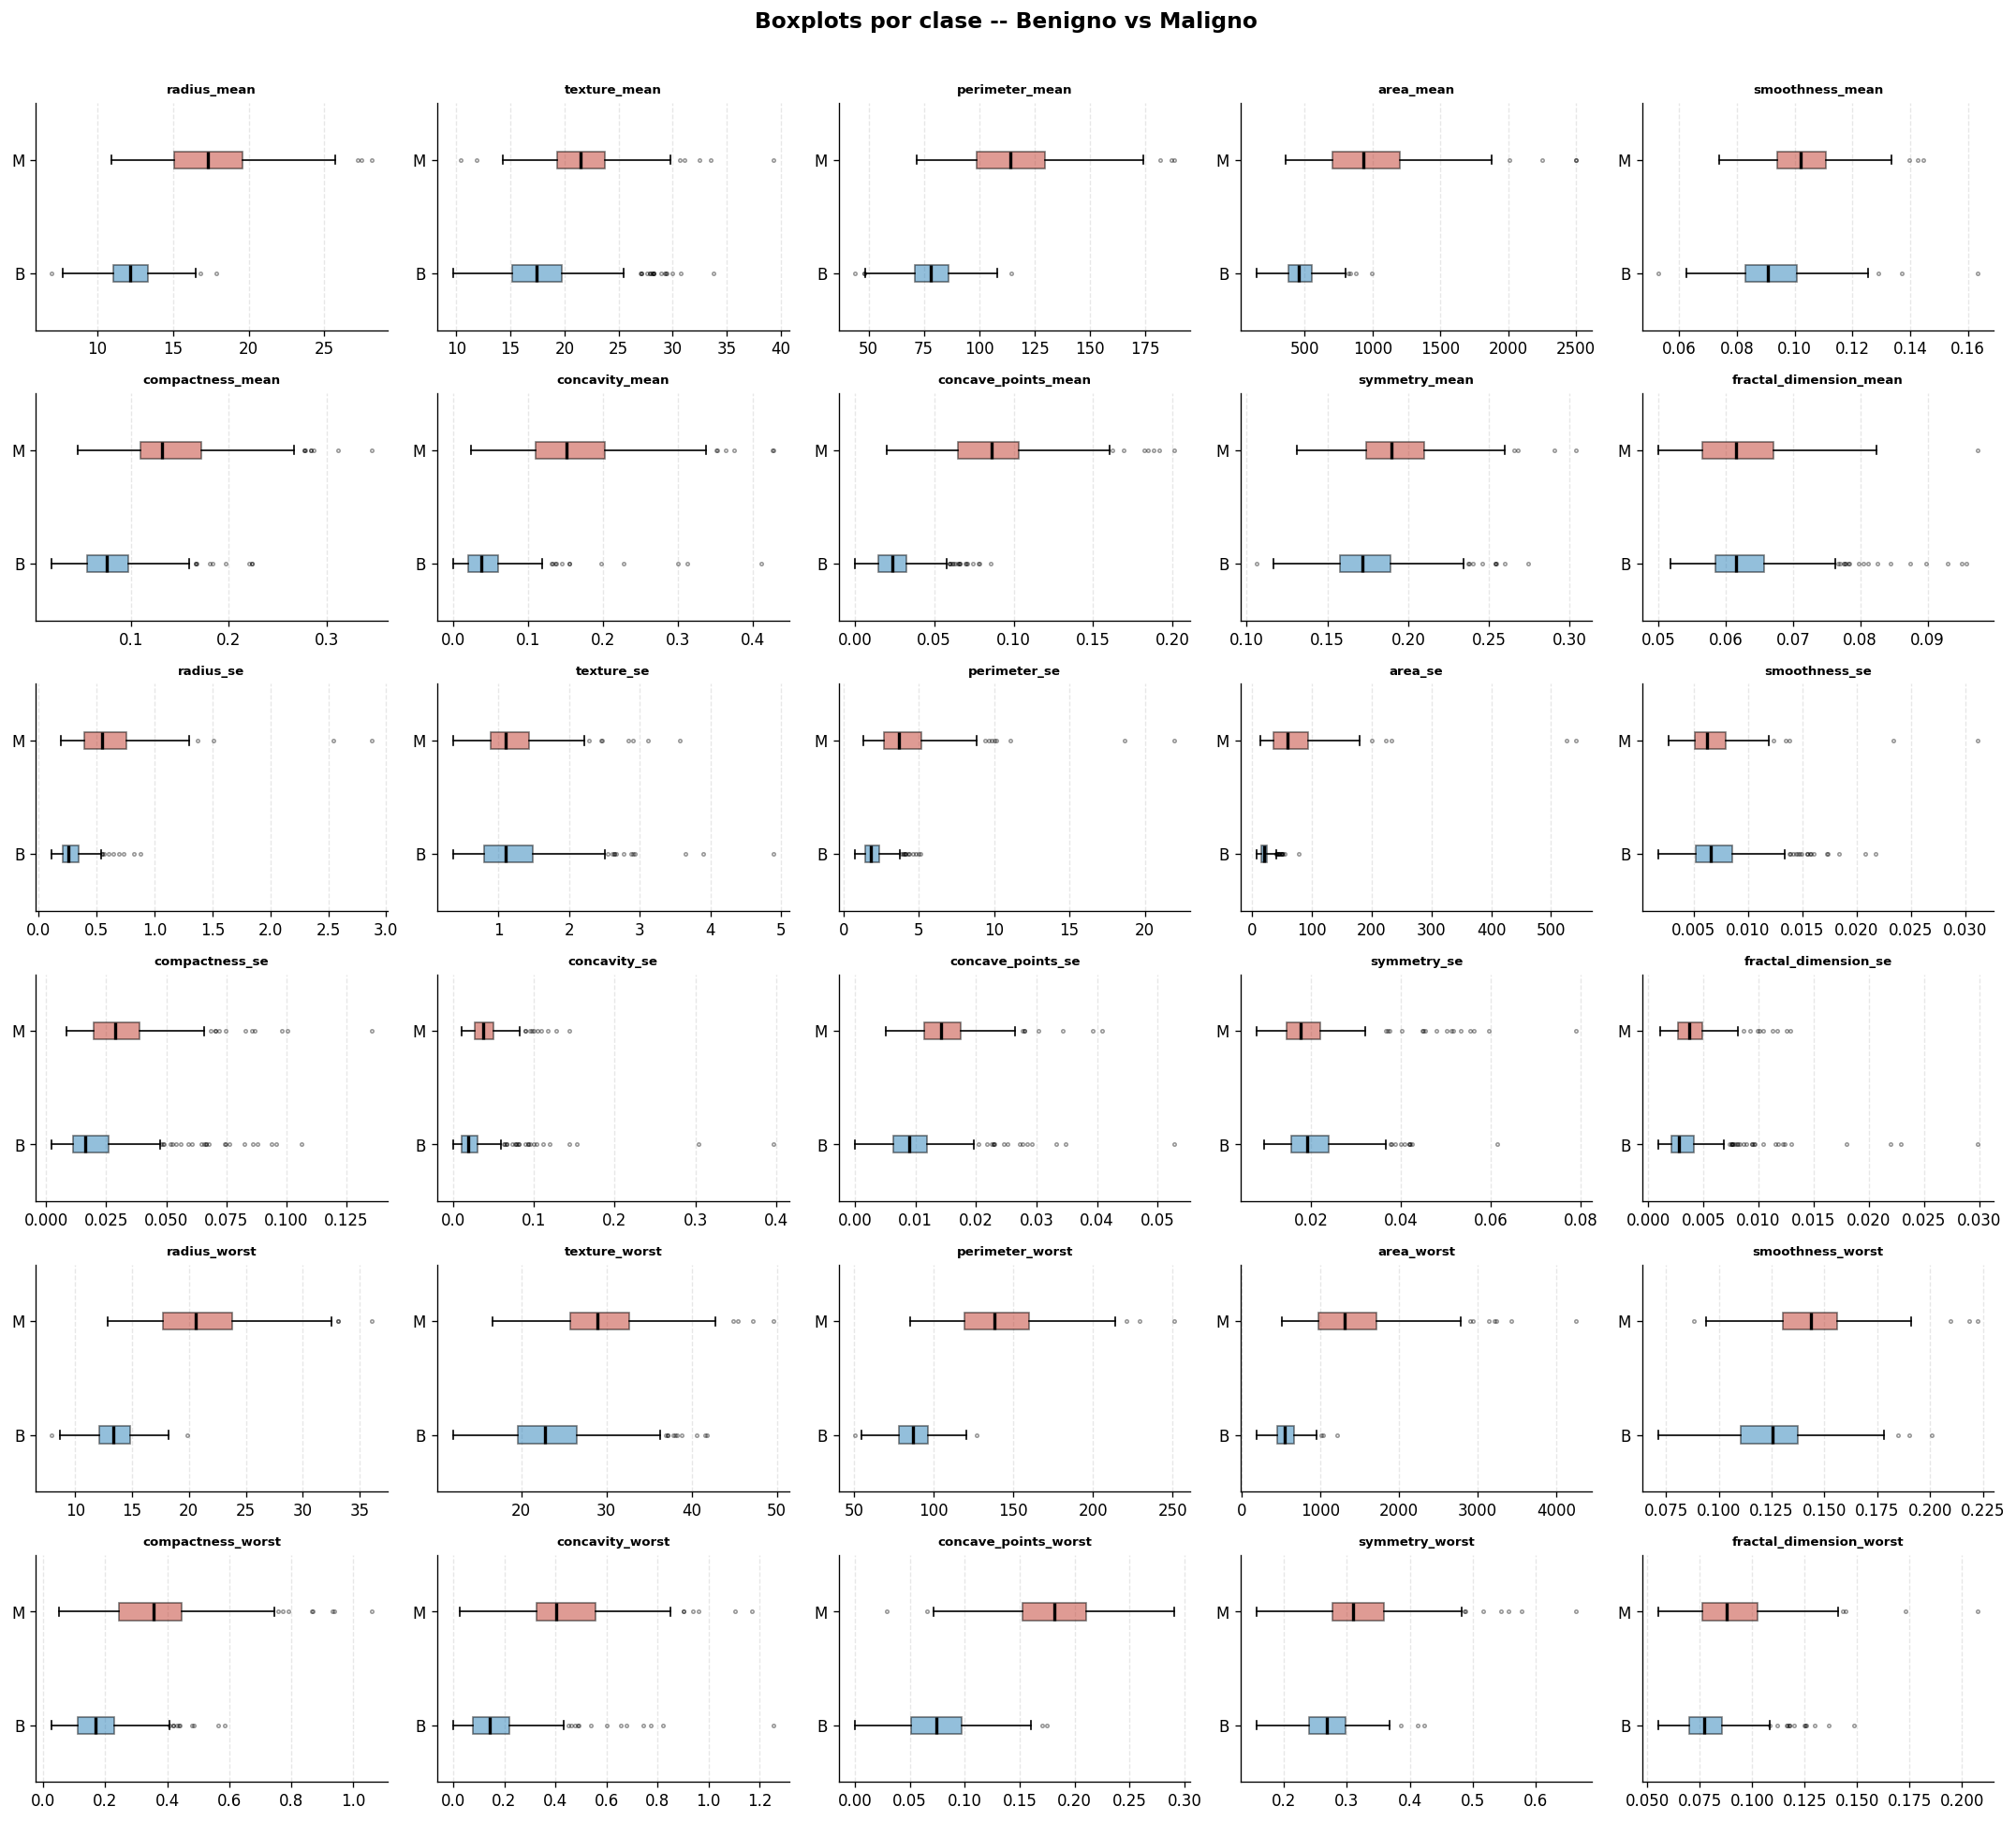

In [10]:
fig, axes = plt.subplots(6, 5, figsize=(18, 16))
fig.suptitle("Boxplots por clase -- Benigno vs Maligno", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features):
    ax = axes.flat[idx]
    b_vals = df.loc[df["diagnosis"] == 0, feat]
    m_vals = df.loc[df["diagnosis"] == 1, feat]
    bp = ax.boxplot([b_vals, m_vals], vert=False, patch_artist=True,
                    labels=["B", "M"],
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.4),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1))
    bp["boxes"][0].set_facecolor("#2980B9")
    bp["boxes"][0].set_alpha(0.5)
    bp["boxes"][1].set_facecolor("#C0392B")
    bp["boxes"][1].set_alpha(0.5)
    ax.set_title(feat, fontsize=8, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

for idx in range(len(features), 30):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Analisis de correlacion

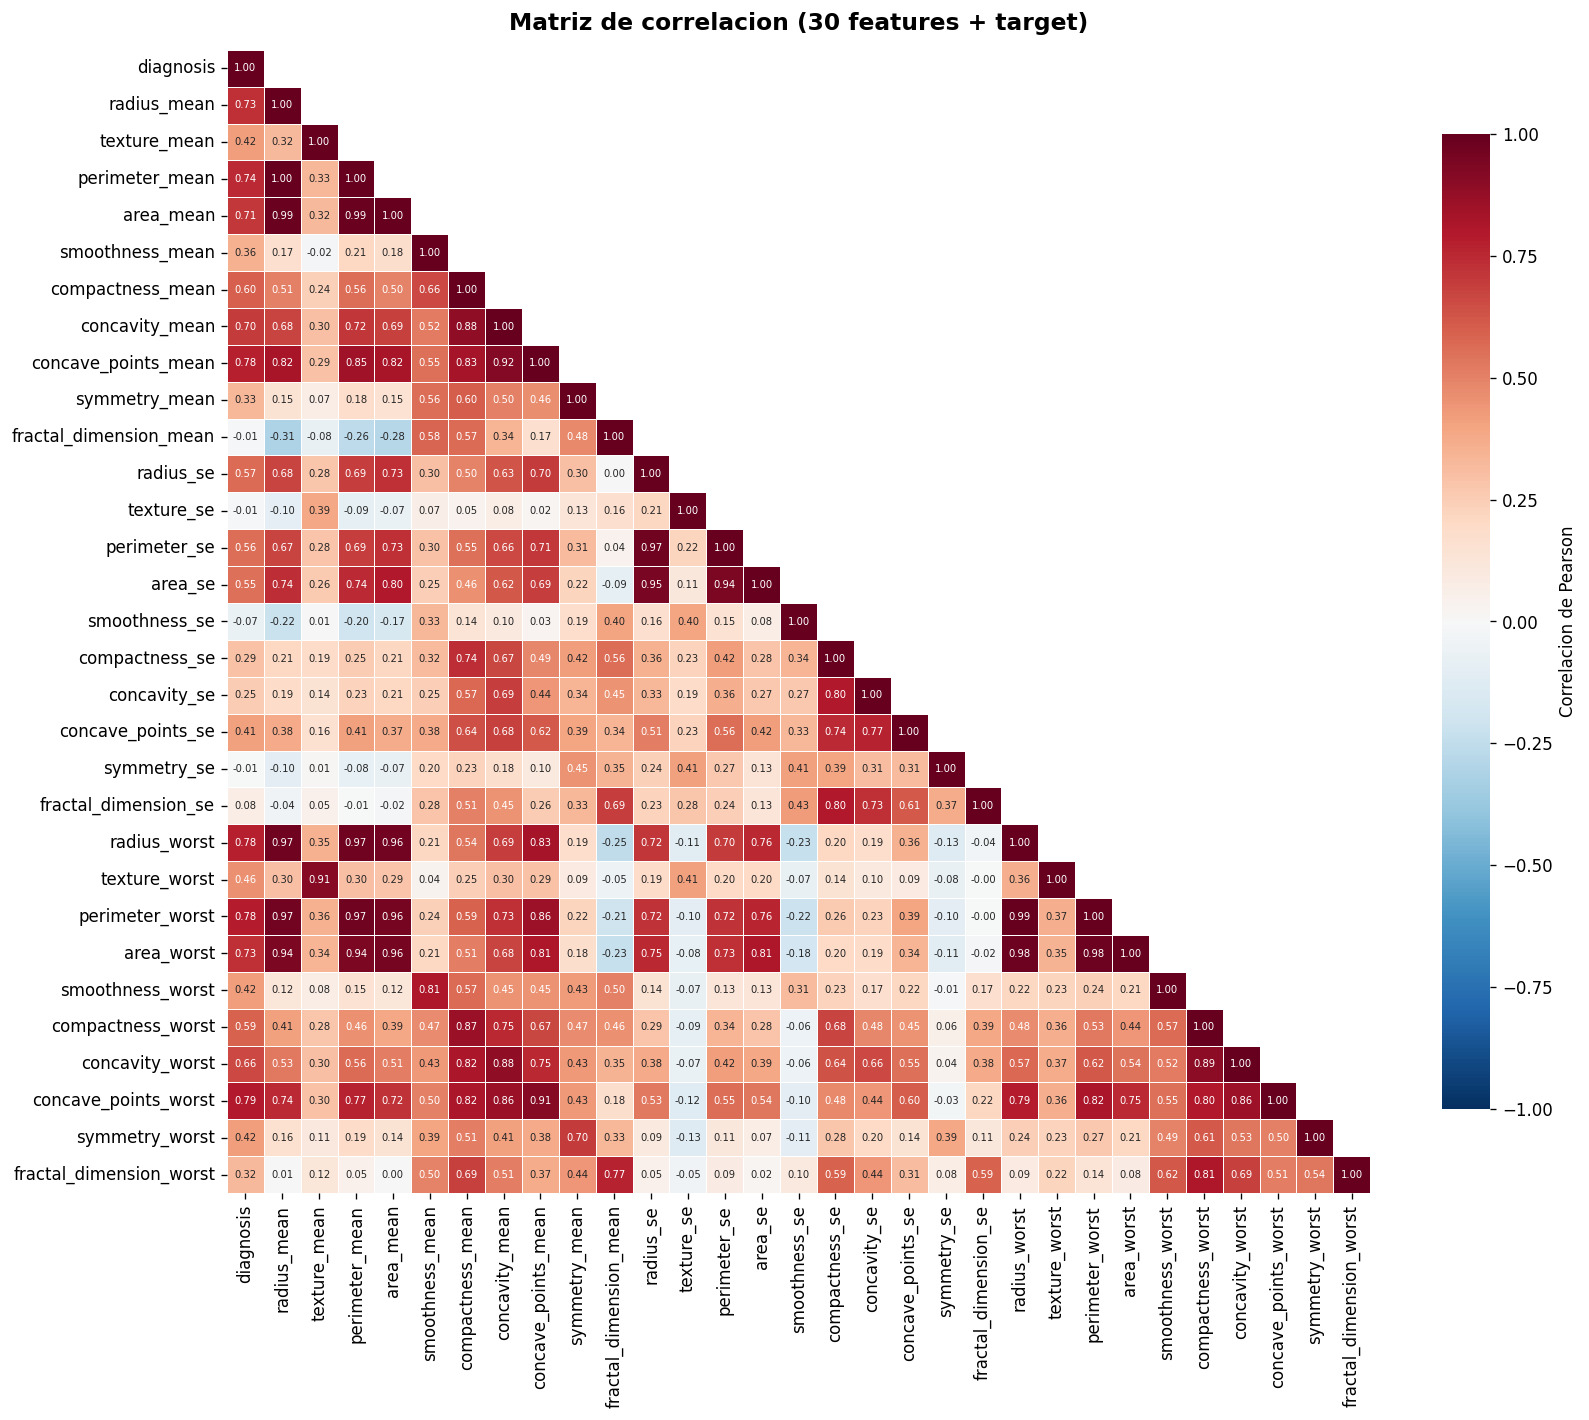

In [11]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlacion de Pearson"},
            annot_kws={"size": 6},
            ax=ax)
ax.set_title("Matriz de correlacion (30 features + target)", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

### Pares con alta correlacion (|r| > 0.70)

In [12]:
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            corr_pairs.append({
                "feature_1": corr.columns[i],
                "feature_2": corr.columns[j],
                "r": round(r, 4),
                "|r|": round(abs(r), 4)
            })

pairs_df = pd.DataFrame(corr_pairs).sort_values("|r|", ascending=False).reset_index(drop=True)
print(f"Pares con |r| > 0.70: {len(pairs_df)}")
pairs_df

Pares con |r| > 0.70: 78


,feature_1,feature_2,r,|r|
0,radius_mean,perimeter_mean,0.9979,0.9979
1,radius_worst,perimeter_worst,0.9937,0.9937
2,radius_mean,area_mean,0.9874,0.9874
3,perimeter_mean,area_mean,0.9865,0.9865
4,radius_worst,area_worst,0.9840,0.9840
...,...,...,...,...
73,radius_se,perimeter_worst,0.7197,0.7197
74,perimeter_mean,concavity_mean,0.7161,0.7161
75,radius_se,radius_worst,0.7151,0.7151
76,concave_points_mean,perimeter_se,0.7106,0.7106


### Correlacion de cada feature con diagnosis (point-biserial)

In [13]:
diag_corr = corr["diagnosis"].drop("diagnosis").sort_values(key=abs, ascending=False)
print("Correlacion con diagnosis (ordenada por |r|):\n")
for feat, r in diag_corr.items():
    print(f"  {feat:30s}  r = {r:+.4f}")

Correlacion con diagnosis (ordenada por |r|):

  concave_points_worst            r = +0.7936
  perimeter_worst                 r = +0.7829
  concave_points_mean             r = +0.7766
  radius_worst                    r = +0.7765
  perimeter_mean                  r = +0.7426
  area_worst                      r = +0.7338
  radius_mean                     r = +0.7300
  area_mean                       r = +0.7090
  concavity_mean                  r = +0.6964
  concavity_worst                 r = +0.6596
  compactness_mean                r = +0.5965
  compactness_worst               r = +0.5910
  radius_se                       r = +0.5671
  perimeter_se                    r = +0.5561
  area_se                         r = +0.5482
  texture_worst                   r = +0.4569
  smoothness_worst                r = +0.4215
  symmetry_worst                  r = +0.4163
  texture_mean                    r = +0.4152
  concave_points_se               r = +0.4080
  smoothness_mean                

### Correlacion entre mean, SE y worst por feature base

Para cada feature base, analizamos la correlacion entre sus tres estadisticos (mean, SE, worst).
Esto permite aplicar la **opcion C**: si dos estadisticos estan altamente correlacionados
(|r| > 0.80), conservamos el que tiene mayor correlacion absoluta con el target.

In [14]:
stats_labels = ["mean", "se", "worst"]
stat_pairs = []

for feat in FEATURE_NAMES:
    for s1, s2 in [("mean", "se"), ("mean", "worst"), ("se", "worst")]:
        c1, c2 = f"{feat}_{s1}", f"{feat}_{s2}"
        r = df[c1].corr(df[c2])
        r_diag_1 = diag_corr.get(c1, 0)
        r_diag_2 = diag_corr.get(c2, 0)
        stat_pairs.append({
            "feature_base": feat,
            "par": f"{s1} <-> {s2}",
            "r": round(r, 4),
            "|r|": round(abs(r), 4),
            "r_diag_1": round(r_diag_1, 4) if isinstance(r_diag_1, float) else r_diag_1,
            "r_diag_2": round(r_diag_2, 4) if isinstance(r_diag_2, float) else r_diag_2,
            "|r_diag_1|": round(abs(r_diag_1), 4) if isinstance(r_diag_1, float) else abs(r_diag_1),
            "|r_diag_2|": round(abs(r_diag_2), 4) if isinstance(r_diag_2, float) else abs(r_diag_2),
        })

stat_corr_df = pd.DataFrame(stat_pairs)

high_stat = stat_corr_df[stat_corr_df["|r|"] > 0.80].sort_values("|r|", ascending=False)
print(f"Pares mean/se/worst con |r| > 0.80: {len(high_stat)}")
high_stat

Pares mean/se/worst con |r| > 0.80: 10


,feature_base,par,r,|r|,r_diag_1,r_diag_2,|r_diag_1|,|r_diag_2|
7,perimeter,mean <-> worst,0.9704,0.9704,0.7426,0.7829,0.7426,0.7829
1,radius,mean <-> worst,0.9695,0.9695,0.7300,0.7765,0.7300,0.7765
10,area,mean <-> worst,0.9592,0.9592,0.7090,0.7338,0.7090,0.7338
4,texture,mean <-> worst,0.9120,0.9120,0.4152,0.4569,0.4152,0.4569
22,concave_points,mean <-> worst,0.9102,0.9102,0.7766,0.7936,0.7766,0.7936
19,concavity,mean <-> worst,0.8841,0.8841,0.6964,0.6596,0.6964,0.6596
16,compactness,mean <-> worst,0.8658,0.8658,0.5965,0.5910,0.5965,0.5910
11,area,se <-> worst,0.8114,0.8114,0.5482,0.7338,0.5482,0.7338
13,smoothness,mean <-> worst,0.8053,0.8053,0.3586,0.4215,0.3586,0.4215
9,area,mean <-> se,0.8001,0.8001,0.7090,0.5482,0.7090,0.5482


## 6. Feature selection por multicolinealidad

### Criterio

Se eliminan features con alta correlacion entre si (|r| > 0.80). Para cada par
correlacionado, se conserva la feature con mayor correlacion absoluta con el target
(`diagnosis`). Las decisiones se documentan caso por caso.

El proceso se divide en:
1. **Grupo geometrico:** {radius, perimeter, area} -- funcionalmente dependientes.
2. **Features derivadas:** {compactness, concavity, concave_points} -- verificar redundancia.
3. **Estadisticos mean/se/worst:** para cada feature base, si dos estadisticos superan
   |r| > 0.80, conservar el mas discriminativo.

### 6.1 Grupo geometrico: radius, perimeter, area

Estas tres features estan funcionalmente relacionadas:
- perimeter = 2 * pi * radius
- area = pi * radius^2

Por lo tanto, son redundantes. Conservamos la que tiene mayor |r| con diagnosis.

In [15]:
geo_feats = ["radius", "perimeter", "area"]
print("Correlacion con diagnosis y entre si:\n")

for suffix in ["mean", "se", "worst"]:
    print(f"--- {suffix.upper()} ---")
    cols = [f"{f}_{suffix}" for f in geo_feats]
    for c in cols:
        r_diag = diag_corr[c]
        print(f"  {c:25s}  |r(diag)| = {abs(r_diag):.4f}")
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = df[cols[i]].corr(df[cols[j]])
            print(f"  {cols[i]} <-> {cols[j]}: r = {r:.4f}")
    print()

Correlacion con diagnosis y entre si:

--- MEAN ---
  radius_mean                |r(diag)| = 0.7300
  perimeter_mean             |r(diag)| = 0.7426
  area_mean                  |r(diag)| = 0.7090


  radius_mean <-> perimeter_mean: r = 0.9979
  radius_mean <-> area_mean: r = 0.9874
  perimeter_mean <-> area_mean: r = 0.9865

--- SE ---
  radius_se                  |r(diag)| = 0.5671
  perimeter_se               |r(diag)| = 0.5561
  area_se                    |r(diag)| = 0.5482
  radius_se <-> perimeter_se: r = 0.9728
  radius_se <-> area_se: r = 0.9518
  perimeter_se <-> area_se: r = 0.9377

--- WORST ---
  radius_worst               |r(diag)| = 0.7765
  perimeter_worst            |r(diag)| = 0.7829
  area_worst                 |r(diag)| = 0.7338
  radius_worst <-> perimeter_worst: r = 0.9937
  radius_worst <-> area_worst: r = 0.9840
  perimeter_worst <-> area_worst: r = 0.9776



In [16]:
geo_drop = []
for suffix in ["mean", "se", "worst"]:
    cols = {f: f"{f}_{suffix}" for f in geo_feats}
    r_diag = {f: abs(diag_corr[c]) for f, c in cols.items()}
    best = max(r_diag, key=r_diag.get)
    dropped = [f for f in geo_feats if f != best]
    for d in dropped:
        geo_drop.append(f"{d}_{suffix}")
    print(f"{suffix}: conservo {best}_{suffix} (|r|={r_diag[best]:.4f}), "
          f"dropeo {', '.join(f'{d}_{suffix}' for d in dropped)}")

print(f"\nTotal features geometricas a eliminar: {len(geo_drop)}")

mean: conservo perimeter_mean (|r|=0.7426), dropeo radius_mean, area_mean
se: conservo radius_se (|r|=0.5671), dropeo perimeter_se, area_se
worst: conservo perimeter_worst (|r|=0.7829), dropeo radius_worst, area_worst

Total features geometricas a eliminar: 6


### 6.2 Features derivadas: compactness, concavity, concave_points

- **compactness** = perimeter^2 / area - 1 (derivada de perimeter y area)
- **concavity**: severidad de las porciones concavas del contorno
- **concave_points**: cantidad de porciones concavas

Compactness es una formula de perimeter y area (ya eliminadas parcialmente), pero
debemos verificar si las tres features son redundantes entre si.

In [17]:
derived_feats = ["compactness", "concavity", "concave_points"]
print("Correlacion con diagnosis y entre si:\n")

for suffix in ["mean", "se", "worst"]:
    print(f"--- {suffix.upper()} ---")
    cols = [f"{f}_{suffix}" for f in derived_feats]
    for c in cols:
        print(f"  {c:25s}  |r(diag)| = {abs(diag_corr[c]):.4f}")
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = df[cols[i]].corr(df[cols[j]])
            flag = " <-- ALTA" if abs(r) > 0.80 else ""
            print(f"  {cols[i]} <-> {cols[j]}: r = {r:.4f}{flag}")
    print()

Correlacion con diagnosis y entre si:

--- MEAN ---
  compactness_mean           |r(diag)| = 0.5965
  concavity_mean             |r(diag)| = 0.6964
  concave_points_mean        |r(diag)| = 0.7766
  compactness_mean <-> concavity_mean: r = 0.8831 <-- ALTA
  compactness_mean <-> concave_points_mean: r = 0.8311 <-- ALTA
  concavity_mean <-> concave_points_mean: r = 0.9214 <-- ALTA

--- SE ---
  compactness_se             |r(diag)| = 0.2930
  concavity_se               |r(diag)| = 0.2537
  concave_points_se          |r(diag)| = 0.4080
  compactness_se <-> concavity_se: r = 0.8013 <-- ALTA
  compactness_se <-> concave_points_se: r = 0.7441
  concavity_se <-> concave_points_se: r = 0.7718

--- WORST ---
  compactness_worst          |r(diag)| = 0.5910
  concavity_worst            |r(diag)| = 0.6596
  concave_points_worst       |r(diag)| = 0.7936
  compactness_worst <-> concavity_worst: r = 0.8923 <-- ALTA
  compactness_worst <-> concave_points_worst: r = 0.8011 <-- ALTA
  concavity_worst <-> 

In [18]:
derived_drop = []
for suffix in ["mean", "se", "worst"]:
    cols = {f: f"{f}_{suffix}" for f in derived_feats}
    r_diag = {f: abs(diag_corr[c]) for f, c in cols.items()}

    # Check pairwise correlations among these 3
    remaining = list(derived_feats)
    local_drop = []

    pairs_to_check = [
        ("concavity", "concave_points"),
        ("compactness", "concavity"),
        ("compactness", "concave_points"),
    ]

    for f1, f2 in pairs_to_check:
        if f1 not in remaining or f2 not in remaining:
            continue
        c1, c2 = cols[f1], cols[f2]
        r = abs(df[c1].corr(df[c2]))
        if r > 0.80:
            worse = f1 if r_diag[f1] <= r_diag[f2] else f2
            local_drop.append(worse)
            remaining = [f for f in remaining if f != worse]

    for d in local_drop:
        derived_drop.append(f"{d}_{suffix}")

    kept = [f"{f}_{suffix}" for f in remaining]
    print(f"{suffix}: conservo {kept}, dropeo {local_drop}")

print(f"\nTotal features derivadas a eliminar: {len(derived_drop)}")

mean: conservo ['concave_points_mean'], dropeo ['concavity', 'compactness']
se: conservo ['compactness_se', 'concave_points_se'], dropeo ['concavity']
worst: conservo ['concave_points_worst'], dropeo ['concavity', 'compactness']

Total features derivadas a eliminar: 5


### 6.3 Estadisticos mean/se/worst (opcion C)

Para cada feature base (excluyendo las ya analizadas), verificamos si mean, SE y worst
estan altamente correlacionados entre si. Si |r| > 0.80, conservamos el de mayor
|r| con diagnosis.

In [19]:
remaining_bases = [f for f in FEATURE_NAMES if f not in geo_feats and f not in derived_feats]
print(f"Features base restantes: {remaining_bases}")

stat_drop = []
for feat in remaining_bases:
    cols = {s: f"{feat}_{s}" for s in stats_labels}
    r_diag = {s: abs(diag_corr[c]) for s, c in cols.items()}

    remaining = list(stats_labels)
    local_drop = []

    for s1, s2 in [("mean", "worst"), ("mean", "se"), ("se", "worst")]:
        if s1 not in remaining or s2 not in remaining:
            continue
        r = abs(df[cols[s1]].corr(df[cols[s2]]))
        if r > 0.80:
            worse = s1 if r_diag[s1] <= r_diag[s2] else s2
            local_drop.append(worse)
            remaining = [s for s in remaining if s != worse]

    for d in local_drop:
        stat_drop.append(f"{feat}_{d}")

    kept = [f"{feat}_{s}" for s in remaining]
    if local_drop:
        print(f"{feat}: conservo {kept}, dropeo {[f'{feat}_{d}' for d in local_drop]}")
    else:
        print(f"{feat}: conservo todos ({kept})")

print(f"\nTotal features de estadisticos a eliminar: {len(stat_drop)}")

Features base restantes: ['texture', 'smoothness', 'symmetry', 'fractal_dimension']
texture: conservo ['texture_se', 'texture_worst'], dropeo ['texture_mean']
smoothness: conservo ['smoothness_se', 'smoothness_worst'], dropeo ['smoothness_mean']
symmetry: conservo todos (['symmetry_mean', 'symmetry_se', 'symmetry_worst'])
fractal_dimension: conservo todos (['fractal_dimension_mean', 'fractal_dimension_se', 'fractal_dimension_worst'])

Total features de estadisticos a eliminar: 2


### 6.4 Ejecutar la limpieza

In [20]:
all_drop = set(geo_drop + derived_drop + stat_drop)
features_final = [c for c in features if c not in all_drop]

df_clean = df[features_final + ["diagnosis"]].copy()

print(f"Features originales:  {len(features)}")
print(f"Features eliminadas:  {len(all_drop)}")
print(f"Features finales:     {len(features_final)}")
print(f"\nFeatures conservadas:")
for f in features_final:
    print(f"  {f}")

Features originales:  30
Features eliminadas:  13
Features finales:     17

Features conservadas:
  perimeter_mean
  concave_points_mean
  symmetry_mean
  fractal_dimension_mean
  radius_se
  texture_se
  smoothness_se
  compactness_se
  concave_points_se
  symmetry_se
  fractal_dimension_se
  texture_worst
  perimeter_worst
  smoothness_worst
  concave_points_worst
  symmetry_worst
  fractal_dimension_worst


### 6.5 Resumen de features eliminadas

| Feature eliminada | Feature conservada (misma base) | |r| entre ellas | Razon |
|---|---|---|---|


In [21]:
eliminated = sorted(all_drop)

print("| Feature eliminada | Motivo |")
print("|---|---|")
for feat in eliminated:
    base = "_".join(feat.split("_")[:-1])
    stat = feat.split("_")[-1]
    kept_equiv = [f for f in features_final if f.startswith(base + "_") and f != feat]
    if kept_equiv:
        r = abs(df[feat].corr(df[kept_equiv[0]]))
        print(f"| {feat} | Altamente correlacionada con {kept_equiv[0]} (r={r:.4f}), menor |r(diag)| |")
    else:
        print(f"| {feat} | Feature derivada / geometrica redundante |")

| Feature eliminada | Motivo |
|---|---|
| area_mean | Feature derivada / geometrica redundante |
| area_se | Feature derivada / geometrica redundante |
| area_worst | Feature derivada / geometrica redundante |
| compactness_mean | Altamente correlacionada con compactness_se (r=0.7387), menor |r(diag)| |
| compactness_worst | Altamente correlacionada con compactness_se (r=0.6788), menor |r(diag)| |
| concavity_mean | Feature derivada / geometrica redundante |
| concavity_se | Feature derivada / geometrica redundante |
| concavity_worst | Feature derivada / geometrica redundante |
| perimeter_se | Altamente correlacionada con perimeter_mean (r=0.6931), menor |r(diag)| |
| radius_mean | Altamente correlacionada con radius_se (r=0.6791), menor |r(diag)| |
| radius_worst | Altamente correlacionada con radius_se (r=0.7151), menor |r(diag)| |


| smoothness_mean | Altamente correlacionada con smoothness_se (r=0.3324), menor |r(diag)| |
| texture_mean | Altamente correlacionada con texture_se (r=0.3864), menor |r(diag)| |


## 7. Outlier check

Analizamos outliers estadisticos (IQR * 1.5) sobre las features finales del dataset limpio.
En un dataset medico como este, los outliers representan tumores inusualmente grandes
o con formas irregulares -- son datos reales, no errores de medicion.

In [22]:
features_clean = [c for c in df_clean.columns if c != "diagnosis"]

outlier_summary = []
for feat in features_clean:
    vals = df_clean[feat]
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((vals < lower) | (vals > upper)).sum()
    pct = 100 * n_out / len(vals)

    n_b = ((df_clean.loc[df_clean["diagnosis"] == 0, feat] < lower) |
           (df_clean.loc[df_clean["diagnosis"] == 0, feat] > upper)).sum()
    n_m = ((df_clean.loc[df_clean["diagnosis"] == 1, feat] < lower) |
           (df_clean.loc[df_clean["diagnosis"] == 1, feat] > upper)).sum()

    outlier_summary.append({
        "feature": feat,
        "n_outliers": n_out,
        "pct": round(pct, 1),
        "en_B": n_b,
        "en_M": n_m
    })

out_df = pd.DataFrame(outlier_summary).sort_values("pct", ascending=False)
print("Outliers IQR (1.5) por feature en dataset limpio:")
out_df

Outliers IQR (1.5) por feature en dataset limpio:


,feature,n_outliers,pct,en_B,en_M
4,radius_se,38,6.7,1,37
6,smoothness_se,30,5.3,26,4
7,compactness_se,28,4.9,14,14
10,fractal_dimension_se,28,4.9,18,10
9,symmetry_se,27,4.7,11,16
16,fractal_dimension_worst,24,4.2,6,18
15,symmetry_worst,23,4.0,1,22
5,texture_se,20,3.5,14,6
8,concave_points_se,19,3.3,7,12
2,symmetry_mean,15,2.6,6,9


### Conclusion sobre outliers

**No se eliminan outliers.** Los datos provienen de mediciones de imagenes medicas con
4 digitos significativos. Los valores extremos representan tumores con caracteristicas
inusuales, que son precisamente los casos clinicamente relevantes que el modelo necesita
aprender a clasificar. Eliminarlos seria contraproducente para la deteccion de cancer.

## 8. Comparacion antes/despues de la limpieza

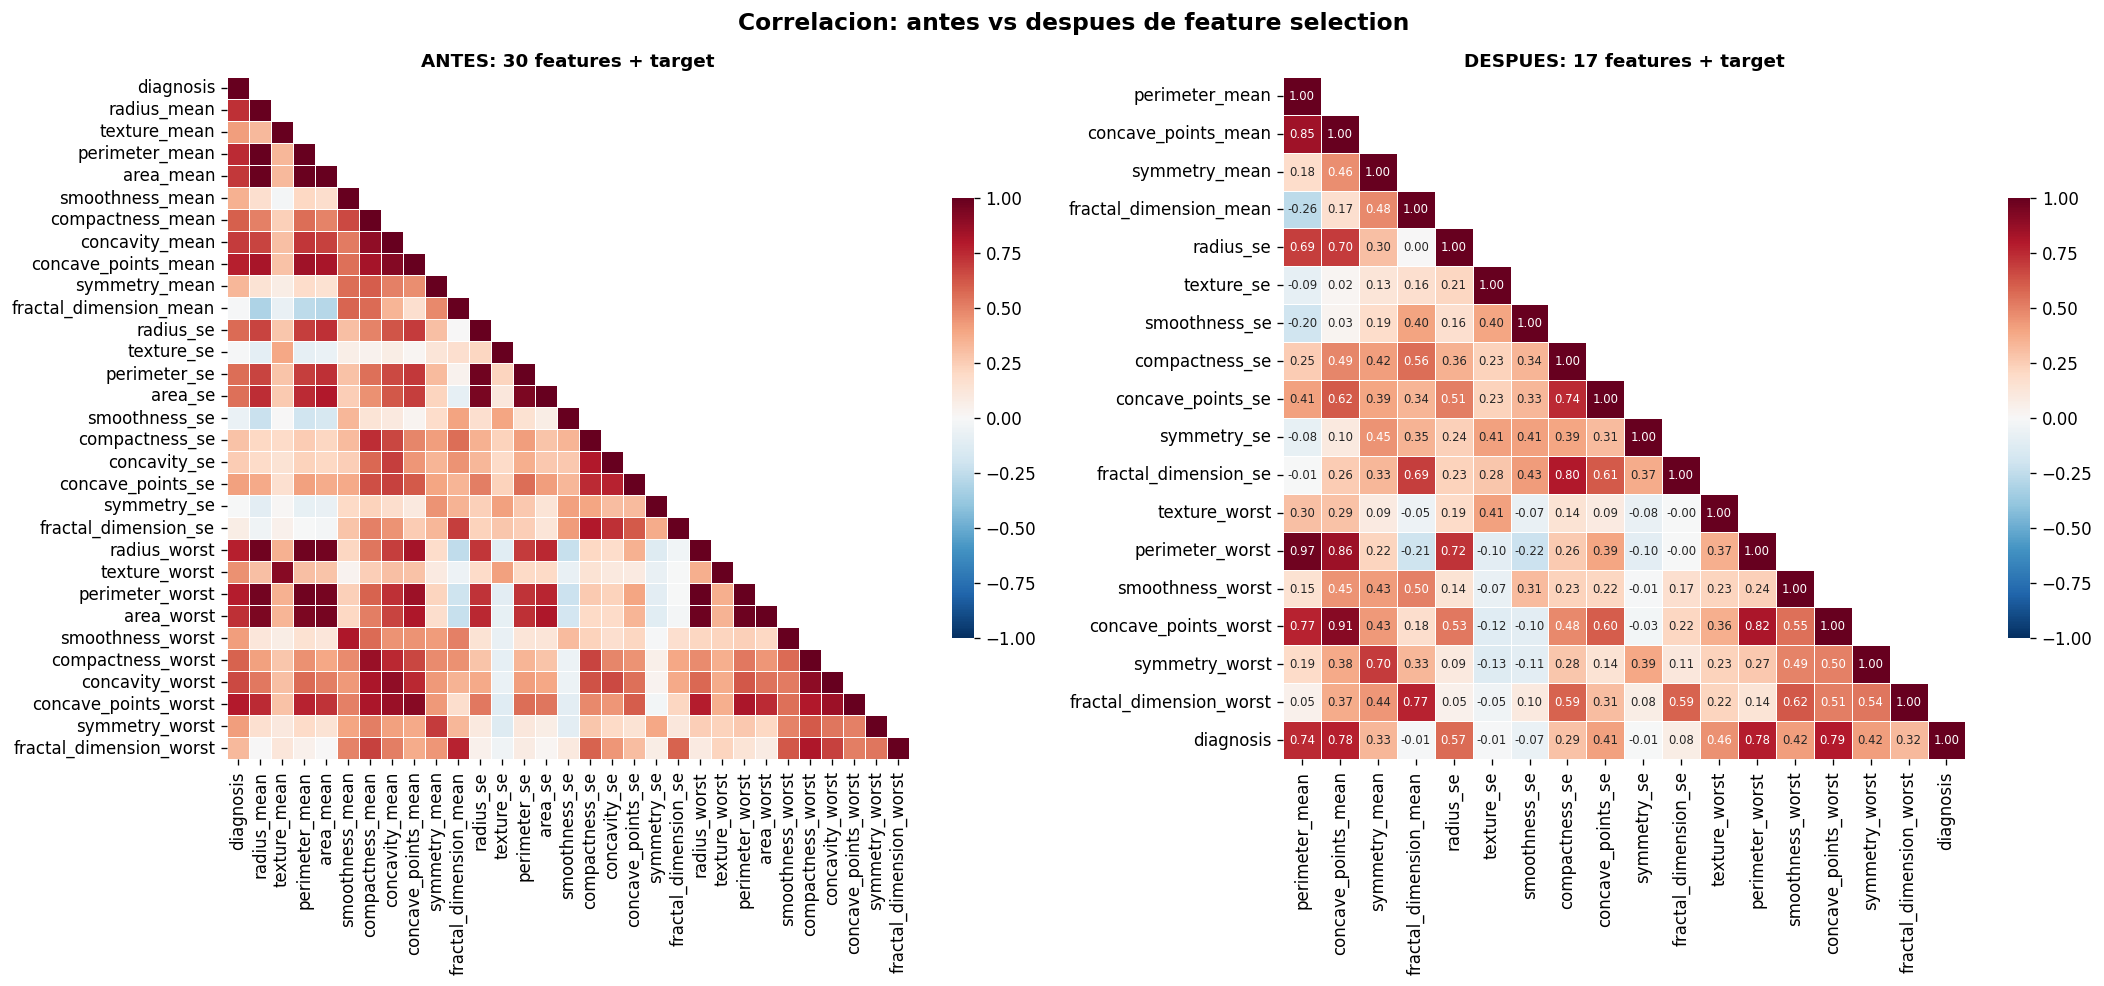

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Antes
corr_before = df.corr()
mask_before = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, mask=mask_before, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.6},
            annot_kws={"size": 5}, ax=axes[0])
axes[0].set_title(f"ANTES: {len(features)} features + target", fontsize=11, fontweight="bold")

# Despues
corr_after = df_clean.corr()
mask_after = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, mask=mask_after, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.6},
            annot_kws={"size": 7}, ax=axes[1])
axes[1].set_title(f"DESPUES: {len(features_clean)} features + target", fontsize=11, fontweight="bold")

plt.suptitle("Correlacion: antes vs despues de feature selection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
print("=" * 60)
print("RESUMEN DE LA LIMPIEZA")
print("=" * 60)
print(f"Features originales:      {len(features)}")
print(f"Features eliminadas:      {len(all_drop)}")
print(f"Features finales:         {len(features_clean)}")
print(f"Instancias:               {len(df_clean)} (sin cambios)")
print(f"Missing values:           {df_clean.isnull().sum().sum()}")
print(f"Outliers eliminados:      0 (datos medicos reales)")
print(f"\nMax |r| entre features finales:")
corr_final = df_clean[features_clean].corr()
max_r = 0
for i in range(len(corr_final.columns)):
    for j in range(i+1, len(corr_final.columns)):
        r = abs(corr_final.iloc[i, j])
        if r > max_r:
            max_r = r
            max_pair = (corr_final.columns[i], corr_final.columns[j])
print(f"  {max_pair[0]} <-> {max_pair[1]}: r = {max_r:.4f}")

RESUMEN DE LA LIMPIEZA
Features originales:      30
Features eliminadas:      13
Features finales:         17
Instancias:               569 (sin cambios)
Missing values:           0
Outliers eliminados:      0 (datos medicos reales)

Max |r| entre features finales:
  perimeter_mean <-> perimeter_worst: r = 0.9704


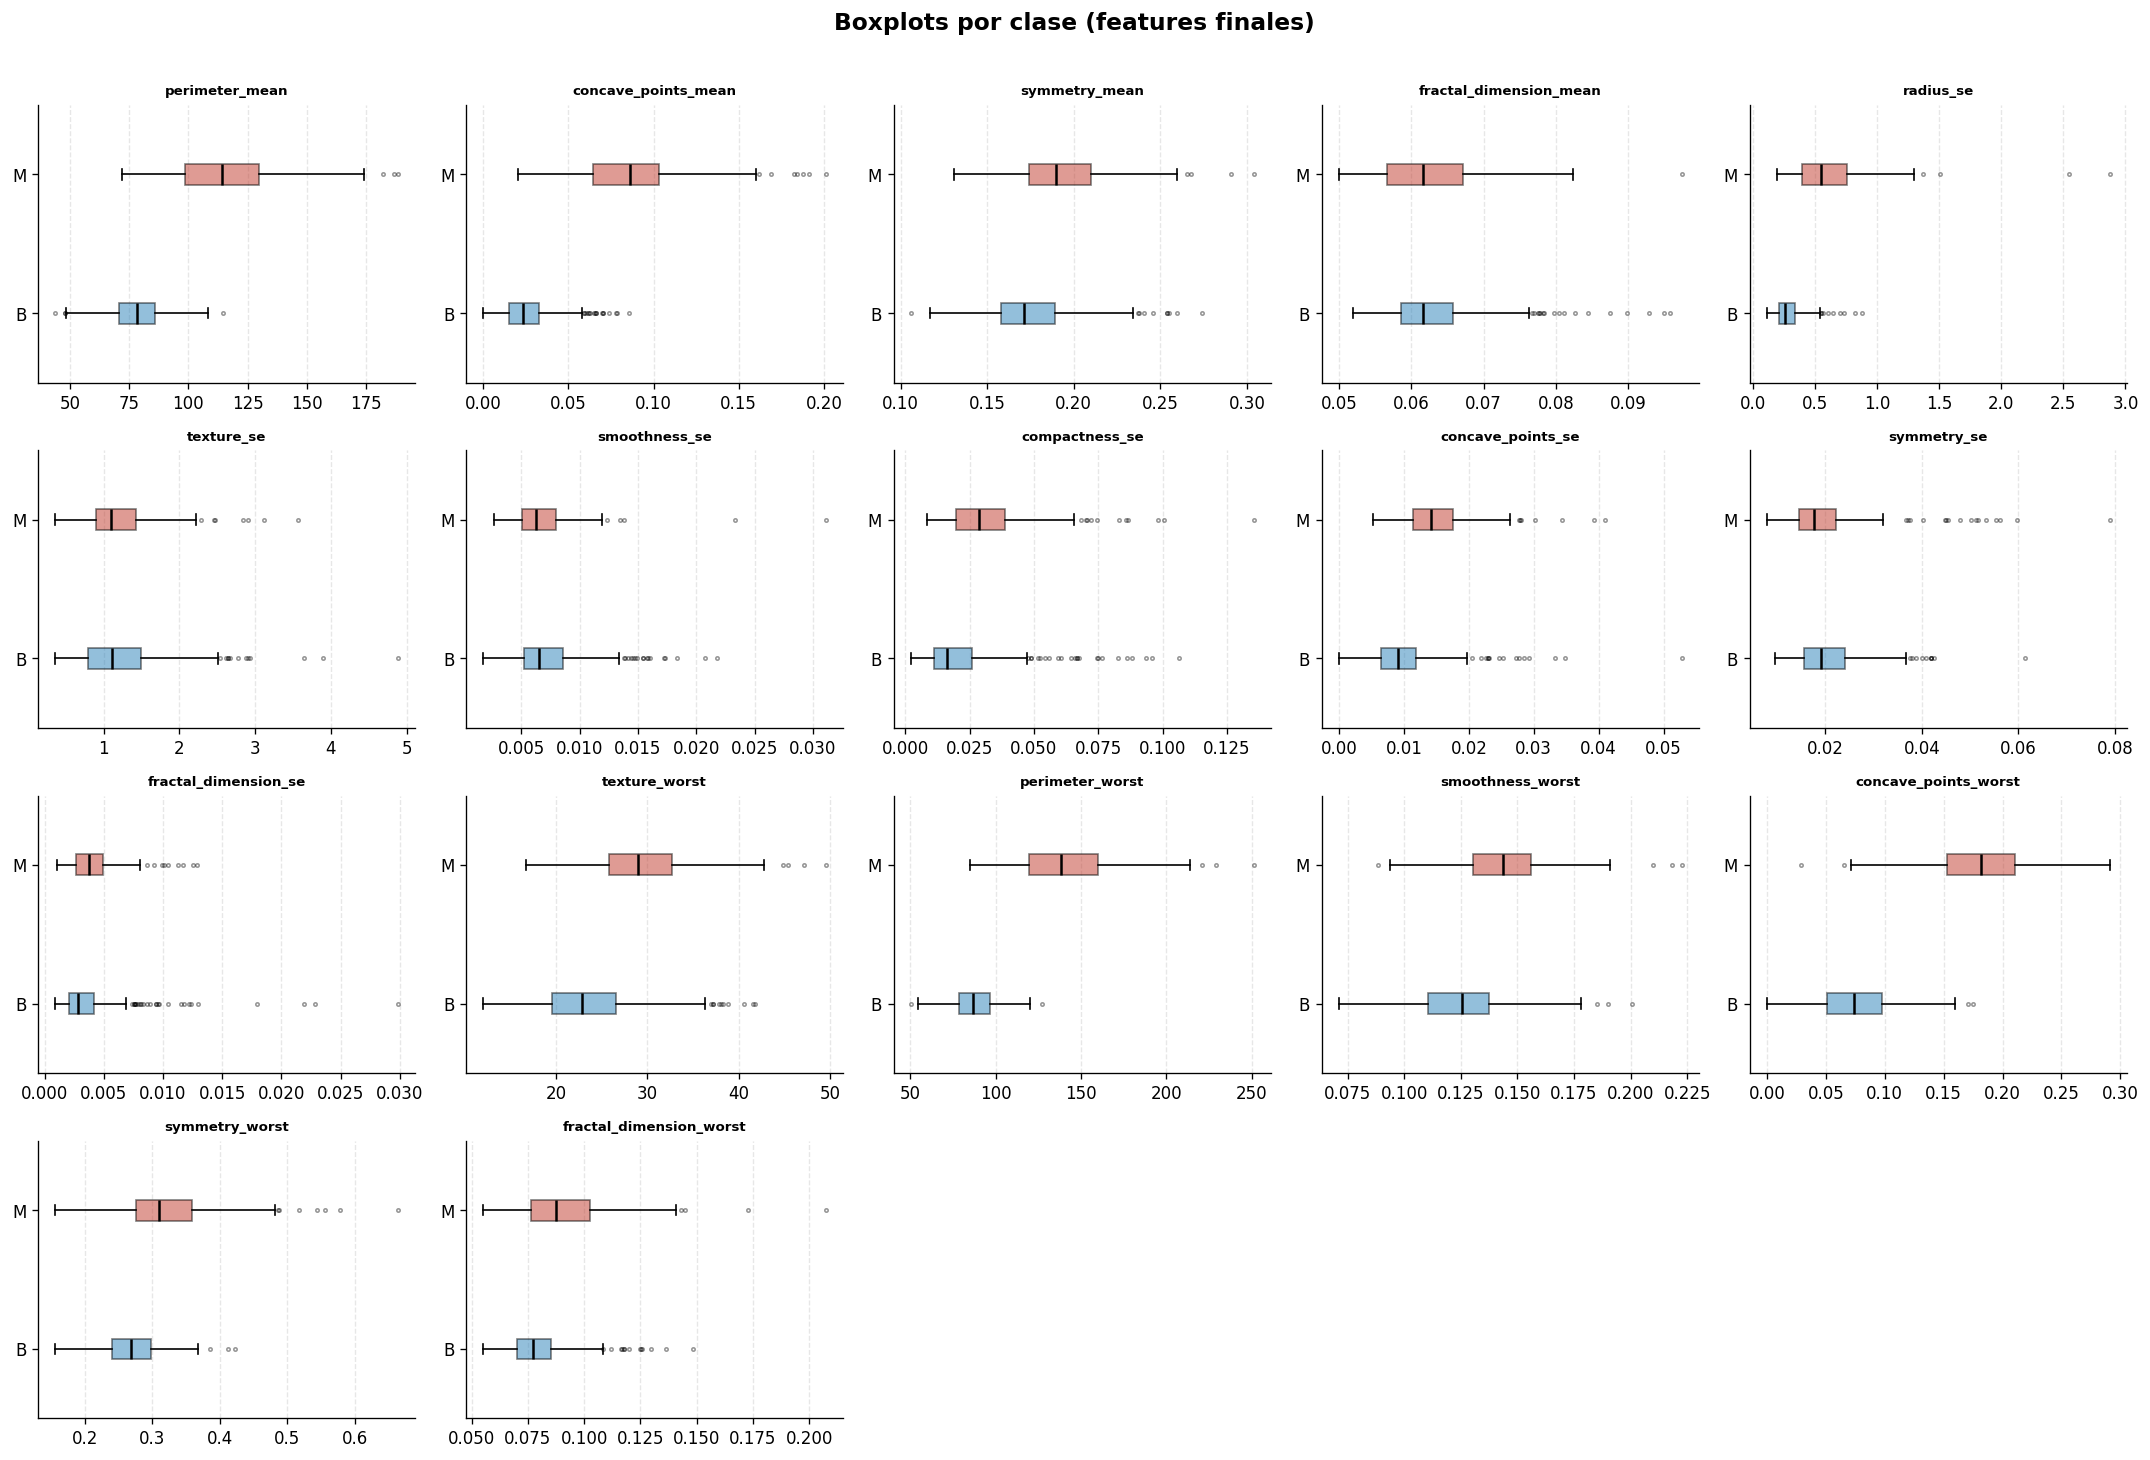

In [25]:
fig, axes = plt.subplots(nrows=max(1, -(-len(features_clean)//5)), ncols=min(len(features_clean), 5),
                       figsize=(min(len(features_clean)*2, 18), max(4, -(-len(features_clean)//5)*3)))
if len(features_clean) <= 5:
    axes = axes.reshape(1, -1)

fig.suptitle("Boxplots por clase (features finales)", fontsize=14, fontweight="bold", y=1.01)

for idx, feat in enumerate(features_clean):
    row, col = divmod(idx, 5)
    ax = axes[row, col]
    b_vals = df_clean.loc[df_clean["diagnosis"] == 0, feat]
    m_vals = df_clean.loc[df_clean["diagnosis"] == 1, feat]
    bp = ax.boxplot([b_vals, m_vals], vert=False, patch_artist=True,
                    labels=["B", "M"],
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=2, alpha=0.4),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1))
    bp["boxes"][0].set_facecolor("#2980B9")
    bp["boxes"][0].set_alpha(0.5)
    bp["boxes"][1].set_facecolor("#C0392B")
    bp["boxes"][1].set_alpha(0.5)
    ax.set_title(feat, fontsize=8, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

for idx in range(len(features_clean), axes.size):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Split estratificado y export

### Estrategia: stratified split + k-fold cross-validation

**Paso 1 -- Separar test (holdout final):**

Reservamos un 20% del dataset como test set, usando `train_test_split` con `stratify=y`.
Esto garantiza que la proporcion B/M sea la misma en ambos conjuntos. El test set **no se
toca** hasta la evaluacion final del modelo.

**Paso 2 -- K-Fold Cross-Validation estratificado sobre train:**

Cada notebook de modelo aplicara StratifiedKFold (k=5) sobre el train set para evaluar
hiperparametros. El escalado (StandardScaler) se hace **dentro del Pipeline de CV** para
evitar data leakage.

**Por que no se escala antes del export:**

Si escalaramos sobre todo el train set y despues hacemos k-fold CV, las estadisticas del
scaler incluirian datos del fold de validacion en cada iteracion. Esto es data leakage.
Al escalar dentro del Pipeline, el scaler se ajusta solo sobre el fold de entrenamiento
en cada iteracion.

```
Dataset limpio (569 filas)
   |
   |-- 80% Train (~455 filas) -- Cada modelo hace K-Fold CV con Pipeline([Scaler, Modelo])
   |
   |-- 20% Test  (~114 filas) -- Evaluacion final unica
```

In [26]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df["diagnosis"] = y_train

test_df = X_test.copy()
test_df["diagnosis"] = y_test

print(f"Train: {len(train_df)} filas  |  Test: {len(test_df)} filas")
print(f"\nDistribucion de diagnosis en cada conjunto:\n")

split_dist = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Train %": (100 * y_train.value_counts().sort_index() / len(y_train)).round(1),
    "Test": y_test.value_counts().sort_index(),
    "Test %": (100 * y_test.value_counts().sort_index() / len(y_test)).round(1),
})
split_dist.index = ["Benigno (0)", "Maligno (1)"]
print(split_dist)

Train: 455 filas  |  Test: 114 filas

Distribucion de diagnosis en cada conjunto:

             Train  Train %  Test  Test %
Benigno (0)    285     62.6    72    63.2
Maligno (1)    170     37.4    42    36.8


In [27]:
os.makedirs("data/processed", exist_ok=True)

train_df.to_csv("data/processed/train.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)

print("Archivos exportados:")
print(f"  data/processed/train.csv ({len(train_df)} filas, {len(train_df.columns)} columnas)")
print(f"  data/processed/test.csv  ({len(test_df)} filas, {len(test_df.columns)} columnas)")
print(f"\nFeatures: {list(X_train.columns)}")

Archivos exportados:
  data/processed/train.csv (455 filas, 18 columnas)
  data/processed/test.csv  (114 filas, 18 columnas)

Features: ['perimeter_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']
